# FEATURE EXTRACTION

In [3]:
# import libraries
import os
import glob
import pandas as pd
import numpy as np
import pyentrp

from pyentrp import entropy as ent

import scipy
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

import math

import xml.etree.ElementTree as ET
import re

# get relevent folders
curfolder = os.getcwd()
print(curfolder)

flesh_folder = os.path.dirname(curfolder)
motion_processing = flesh_folder + '/Motion_Processing_Folder'

mtfolder = motion_processing + '/TS_movement/'
print(mtfolder)

mtfiles = glob.glob(mtfolder + '*.csv')

demographics = curfolder + "/demographicsProcessed.csv"
demographics_nijmegen = curfolder + '/demographicsProcessedNijmegen.csv'

which_arm = curfolder + '/which_arm.csv'
which_arm = pd.read_csv(which_arm)



c:\Users\kadava\Documents\Github\FLESH_IteratedLearning\Feature_Extraction_Folder
c:\Users\kadava\Documents\Github\FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/


In [ ]:
# returns the total movement of a key point given inputed key point and motion processed file
# This function is specifically relevent if you wish to calculate each side's arm movement seprately
def gesturespace2D(sample, joint, side, movement_type): 
    #get the subdf for where there is only movement for that tier. 
    fileID = sample["fileID"][0]
    total_movement = int(0)
    movement_sample = sample[sample[movement_type] == 'movement']
    # if the movement type is arms, then check whether the left or right arm has movement and output accordingly. 
    if movement_type == 'arms':
        if side == "LEFT_": 
            arm = 'l'
        if side == "RIGHT_":
            arm = 'r'
        # if that specific arm has no movement, return zero
        if not which_arm.loc[which_arm['fileID'] == fileID, 'arms'].isin([arm, 'b']).any():
            print(f"fileID {fileID} has no movement in {side} arm for {movement_type}")
            return 0
        # if that specific arm does have movement, return the movement
    # if it is no arms, return the movement
    if movement_sample.empty:
        print(f"fileID {fileID} has no movement for {movement_type}")
        return 0
    else:
        X_std = np.std(movement_sample["X_" + side + joint])
        Y_std = np.std(movement_sample["Y_" + side + joint])
        total_movement = X_std + Y_std # FLAG: hm, should this really be a sumation or rather squared suM??
        return total_movement


# returns the total entropy of a key point given inputed key point and motion processed file
# This function is specifically relevent if you wish to calculate each side's arm movement seprately
def entropyts2D(sample, joint, side, movement_type):
    fileID = sample["fileID"][0]
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_type == 'arms':
        if side == "LEFT_": 
            arm = 'l'
        if side == "RIGHT_":
            arm = 'r'
        # if that specific arm has no movement, return zero
        if not which_arm.loc[which_arm['fileID'] == fileID, 'arms'].isin([arm, 'b']).any():
            return 0
        # if that specific arm does have movement, return the movement
    if movement_sample.empty:
        return 0
    else:
        speed_ts = (movement_sample[side + joint + "_speed2D"]).values
        sample_entropy = ent.sample_entropy(speed_ts, 1)
        return sample_entropy
    
# returns the total entropy of a key point given inputed key point and motion processed file
# This function is specifically relevent if you wish to calculate arm movement using the combined timeseries
def entropyts2Daggregated(sample, joint, movement_type):
    fileID = sample["fileID"][0]
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    else:
        speed_ts = (movement_sample[joint + "_speed2D"]).values
        sample_entropy = ent.sample_entropy(speed_ts, 1)
        return sample_entropy


# returns the total temporal variability of a key point given inputed key point and motion processed file
# This function is specifically relevent if you wish to calculate each side's arm movement seprately
def temporal_variability_function2D(sample, joint, side, movement_type):
    fileID = sample["fileID"][0]
    #get the subdf for where there is only movement for that tier. 
    movement_sample = sample[sample[movement_type] == "movement"]
    # calculate each arm separately if there is arm movement
    if movement_type == 'arms':
        if side == "LEFT_": 
            arm = 'l'
        if side == "RIGHT_":
            arm = 'r'
        # if that specific arm has no movement, return zero
        if not which_arm.loc[which_arm['fileID'] == fileID, 'arms'].isin([arm, 'b']).any():
            return (0,0)
    if movement_sample.empty:
        return (0, 0)
    else:
        # find the average speed of the speed time series
        speed_ts = (movement_sample[side + joint + "_speed2D"]).to_numpy()
        avg_height = np.mean(speed_ts)
        # calculate the peaks in the speed timeseries with the average speed as the min peak height.
        peaks, _ = scipy.signal.find_peaks(speed_ts, avg_height)
        # determine if there are more than two peaks
        if len(peaks) > 2:
            diff_in_peaks = np.empty(len(peaks)-1)
            # calulcate all the amounts of time between peaks
            for i in range(len(peaks)-1): 
                current_peak = sample.loc[peaks[i], "time" ]
                next_peak = sample.loc[peaks[i+1], "time" ]
                time_between_peaks = next_peak - current_peak
                diff_in_peaks[i] = time_between_peaks
            # find the standard deviation in peak distance
            temporal_variability= np.std(diff_in_peaks)
            return (temporal_variability, len(peaks))
        else:
            return (0, len(peaks))
        

# returns the total temporal variability of a key point given inputed key point and motion processed file
# This function is specifically relevent if you wish to calculate arm movement using the combined timeseries
def temporal_variability_function2Daggregated(sample, joint, movement_type):
    fileID = sample["fileID"][0]
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_sample.empty:
        return (0,0)
    else:
        # find the average speed of the speed time series
        speed_ts = (movement_sample[joint + "_speed2D"]).to_numpy()
        avg_height = np.mean(speed_ts)
        # calculate the peaks in the speed timeseries with the average speed as the min peak height.
        peaks, _ = scipy.signal.find_peaks(speed_ts, avg_height)
        # determine if there are more than two peaks
        if len(peaks) > 2:
            diff_in_peaks = np.empty(len(peaks)-1)
            # calulcate all the amounts of time between peaks
            for i in range(len(peaks)-1): 
                current_peak = sample.loc[peaks[i], "time" ]
                next_peak = sample.loc[peaks[i+1], "time" ]
                time_between_peaks = next_peak - current_peak
                diff_in_peaks[i] = time_between_peaks
            # find the standard deviation in peak distance
            temporal_variability= np.std(diff_in_peaks)
            return (temporal_variability, len(peaks))
        else:
            return (0, len(peaks))
        
        
    
## feature for the bounding box of movement
def get_bbmv(sample, keypoint, movement_type):
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    # get spans in each dimension
    x_span = sample['X_' + keypoint].max() - sample['X_' + keypoint].min()
    y_span = sample['Y_' + keypoint].max() - sample['Y_' + keypoint].min()
    #z_span = df['Z_' + keypoint].max() - df['Z_' + keypoint].min()

    # calculate bbmv
    bbmv = x_span * y_span #* z_span
    #print(bbmv)
    return bbmv

# feature for intermittency
def get_intermittency(df, keypoint, movement_type):
    movement_sample = df[df[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    jerk_values = df[keypoint + "_TOTAL_jerk2D"]
    speed_values = df[keypoint + "_TOTAL_speed2D"]
    """Calculate the dimensionless smoothness measure using precomputed smoothed jerk and speed."""
    smoothed_jerk = jerk_values
    speed = speed_values
    if not np.all(speed == 0):
        integrated_squared_jerk = np.sum(smoothed_jerk ** 2)
        max_squared_speed = np.max(speed ** 2)
        D3 = len(speed) ** 3
        jerk_dimensionless = integrated_squared_jerk * (D3 / max_squared_speed)
        smoothness = jerk_dimensionless
    else:
        smoothness = np.nan
    return smoothness

#other features to add: 
# we can calculate total time for arms, upper body, lower body, head (for all of the movement types.)
def time(sample, movement_type): 
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    time_start = movement_sample.iloc[0] ['time']
    time_end = movement_sample.iloc[-1]['time']
    total_time = time_end-time_start
    return total_time

#calculates the total time of the whole gesture
def overall_time(sample):
    movement_types = ['arms', 'lower_body', 'upper_body', 'head_mov']
    earliest_time = np.inf
    latest_time = 0
    for movement_type in movement_types:
        movement_sample = sample[sample[movement_type] == "movement"]
        if movement_sample.empty:
            continue
        time_start = movement_sample.iloc[0] ['time']
        time_end = movement_sample.iloc[-1]['time']
        if time_start < earliest_time:
            earliest_time = time_start
        if time_end > latest_time:
            latest_time = time_end
    # calculates the time from the earliest start to the latest end
    overall_time = time_end - time_start
    return overall_time
        
# function to create columns for the mean speed and acceleration of some keypoints: 
# mean speed
# mean acceleration
# sd speed
# sd acceleration

#keypoints: left wrist, right wrist, knee, 
def mean_keypoint(sample, keypoint, side, measure, movement_type):
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    avg_speed = movement_sample[side + keypoint + '_' + measure + '2D'].mean()
    return avg_speed

def sd_keypoint(sample, keypoint, side, measure, movement_type):
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    std_speed = movement_sample[side + keypoint + '_' + measure + '2D'].std()
    return std_speed

def range_keypoint(sample, keypoint, side, measure, movement_type):
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    min_speed = movement_sample[side + keypoint + '_' + measure + '2D'].min()
    max_speed = movement_sample[side + keypoint + '_' + measure + '2D'].max()
    range = max_speed-min_speed
    return range


def integral_keypoint(sample, keypoint, side, measure, movement_type):
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    integral = np.trapezoid(movement_sample[side + keypoint + '_' + measure + '2D'])
    return integral

In [41]:
featuredf = pd.DataFrame()

# gets the survey information
demographics_read = pd.read_csv(demographics) 

demographics_read_nijmegen = pd.read_csv(demographics_nijmegen) 

# adds survey columns to the features csv file
columns_to_add = demographics_read.columns
for col in columns_to_add:
    #if col != 'participantID':
    featuredf[col] = pd.NA
        #print(col)



## THE CODE BLOCK BELOW IS JUST USED TO TEST MY FUNCTIONS ON ONE FILE

In [19]:
# creates the dataframe of features
featuredf = pd.DataFrame()

# gets the survey information
demographics_read = pd.read_csv(demographics) 

# adds survey columns to the features csv file
columns_to_add = demographics_read.columns
for col in columns_to_add:
    featuredf[col] = pd.NA
file = "/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/leise_g_ch2_g18_compr.eaf.csv"

count = 0
sample = sample = pd.read_csv(file)
movement_sample = sample[sample['arms'] == "movement"]
featuredf.loc[count, "fileID"] = (sample["fileID"])[0]


# get the chainID and the participantID and generation number
featuredf.loc[count, "chainID"] = sample["participantID"][0]
chainID = featuredf["chainID"][count]
split_string = chainID.split('ch')[1]
split_string = split_string.split('g')
chain_num = split_string[0]
gen_num = split_string[1]
featuredf.loc[count, "generation_number"] = int(gen_num)
featuredf.loc[count, "chain_number"] = int(chain_num)
participantID = (int(chain_num) - 1) * 20 + int(gen_num)
gesture = featuredf.loc[count, 'fileID'].split("_")[0]
gesture_chain = (re.split(r"_g\d+", featuredf.loc[count, 'fileID'])[0])
featuredf.loc[count, "participantID"] = participantID
featuredf.loc[count, "gesture"] = gesture
featuredf.loc[count, "gesture_chain"] = gesture_chain

# get the demographic information from the survey and puts it in correct row in featuredf 
matching_rows = demographics_read[demographics_read["participantID"] == int(participantID)]
if len(matching_rows) > 0:
    demographic_row = matching_rows.iloc[0]
    matching_row = demographics_read[demographics_read["participantID"] == int(participantID)]
    featuredf.loc[count, columns_to_add] = matching_row.iloc[0].values
else:
    print("no matching demographics row" + "for" + str(participantID))

print(get_bbmv(sample, "LEFT_WRIST", 'arms'))

print(overall_time(sample))
print(time(sample, 'upper_body'))

print(sd_keypoint(sample, "WRIST", "RIGHT_", 'speed', "arms"))
sample

print(integral_keypoint(sample, "WRIST", "RIGHT_", 'speed', "arms"))


print(get_intermittency(sample, "LEFT_WRIST", 'arms'))
sample


0.10398575296187441
0.10398575296187441
4316.666666666663
4316.666666666663
9.24435050649568e-05
0.030685624581640647
202905.98531464214


,time,X_NOSE,Y_NOSE,Z_NOSE,X_LEFT_EYE_INNER,Y_LEFT_EYE_INNER,Z_LEFT_EYE_INNER,X_LEFT_EYE,Y_LEFT_EYE,Z_LEFT_EYE,...,RIGHT_SHOULDER_jerk2D,LEFT_INDEX_jerk2D,LEFT_HIP_jerk2D,RIGHT_EAR_jerk2D,RIGHT_PINKY_jerk2D,ARM_TOTAL_jerk2D,arms,upper_body,head_mov,lower_body
0,0.000000,-0.004960,0.352715,-0.416002,0.018296,0.367055,-0.410150,0.020171,0.366148,-0.397411,...,1.909293e-08,3.801872e-06,4.726405e-08,6.547950e-07,2.530815e-06,4.218288e-06,no movement,no movement,no movement,no movement
1,16.666667,-0.003859,0.353030,-0.415440,0.019273,0.367340,-0.409399,0.021142,0.366451,-0.396656,...,1.421610e-07,-2.857779e-07,-1.015349e-07,-1.456694e-07,1.586750e-06,3.447978e-06,no movement,no movement,no movement,no movement
2,33.333333,-0.002759,0.353344,-0.414878,0.020250,0.367625,-0.408647,0.022113,0.366753,-0.395902,...,1.215382e-07,-3.422226e-06,-1.850191e-07,-6.286869e-07,4.764034e-07,5.715829e-06,no movement,no movement,no movement,no movement
3,50.000000,-0.001658,0.353659,-0.414315,0.021227,0.367909,-0.407895,0.023084,0.367056,-0.395147,...,2.529934e-09,-5.707682e-06,-2.190096e-07,-8.572384e-07,-6.489148e-07,6.868560e-06,no movement,no movement,no movement,no movement
4,66.666667,-0.000558,0.353974,-0.413753,0.022204,0.368194,-0.407144,0.024054,0.367358,-0.394392,...,-1.746141e-07,-7.235604e-06,-2.174431e-07,-8.890738e-07,-1.663930e-06,7.103482e-06,no movement,no movement,no movement,no movement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,5283.333333,-0.042765,0.371160,-0.410049,-0.010693,0.382951,-0.416005,-0.008373,0.382040,-0.402824,...,-5.796202e-07,7.183174e-07,-1.318735e-07,-3.535459e-07,5.891845e-07,8.694712e-07,no movement,no movement,no movement,no movement
318,5300.000000,-0.042844,0.371552,-0.408912,-0.010574,0.383256,-0.415028,-0.008253,0.382355,-0.401859,...,-3.613693e-07,2.135230e-06,-1.118490e-07,-2.544426e-07,1.268551e-06,2.040940e-06,no movement,no movement,no movement,no movement
319,5316.666667,-0.042922,0.371944,-0.407775,-0.010455,0.383560,-0.414051,-0.008133,0.382671,-0.400893,...,5.847372e-08,3.371372e-06,-5.600304e-08,-3.954976e-08,1.875708e-06,3.746515e-06,no movement,no movement,no movement,no movement
320,5333.333333,-0.043001,0.372336,-0.406638,-0.010336,0.383865,-0.413073,-0.008013,0.382987,-0.399928,...,7.197488e-07,4.213433e-06,4.320632e-08,3.182993e-07,2.355475e-06,5.456822e-06,no movement,no movement,no movement,no movement


# Main For Loop For Feature Extraction

In [30]:
count = 0
nijmegen_gestures  = ['koud', 'langzaam', 'nijmegen_nijmegen_rennen', 'onweer', 'stil']
# Loop through all files and extract all gesture features
for file in mtfiles:
    print(file)
    sample = pd.read_csv(file)
    fileID = (sample["fileID"])[0]
    # get the fileID 
    featuredf.loc[count, "fileID"] = (sample["fileID"])[0]

    # get the chainID and the participantID and generation number
    ## need to revise this so that it adds a nijmegen vs lndw column because there are repeat chains and participant ids.
    featuredf.loc[count, "chainID"] = sample["participantID"][0]
    chainID = featuredf["chainID"][count]
    split_string = chainID.split('ch')[1]
    split_string = split_string.split('g')
    chain_num = split_string[0]
    gen_num = split_string[1]
    featuredf.loc[count, "generation_number"] = int(gen_num)
    featuredf.loc[count, "chain_number"] = int(chain_num)
    participantID = (int(chain_num) - 1) * 20 + int(gen_num)
    gesture = featuredf.loc[count, 'fileID'].split("_")[0]
    if gesture == 'lndw':
        gesture = 'lndw_lndw_rennen'
    if gesture == 'nijmegen':
        gesture = 'nijmegen_nijmegen_rennen'
    gesture_chain = (re.split(r"_g\d+", featuredf.loc[count, 'fileID'])[0])
    featuredf.loc[count, "participantID"] = participantID
    featuredf.loc[count, "gesture"] = gesture
    featuredf.loc[count, "gesture_chain"] = gesture_chain

    if any(word in fileID for word in nijmegen_gestures):
        participantID = 'n' + str(participantID)
        featuredf.loc[count, 'event'] = 'nijmegen'
    else: 
        featuredf.loc[count, 'event'] = 'lndw'

    if featuredf.loc[count, 'event'] == 'lndw':
    # get the demographic information from the survey and puts it in correct row in featuredf 
        matching_rows = demographics_read[demographics_read["participantID"] == int(participantID)]
        if len(matching_rows) > 0:
            demographic_row = matching_rows.iloc[0]
            matching_row = demographics_read[demographics_read["participantID"] == int(participantID)]
            featuredf.loc[count, columns_to_add] = matching_row.iloc[0].values
        else:
            print("no matching demographics row" + "for" + str(participantID))
    
    if featuredf.loc[count, 'event'] == 'nijmegen':
    # get the demographic information from the survey and puts it in correct row in featuredf 
        matching_rows = demographics_read_nijmegen[demographics_read_nijmegen["participantID"] == participantID]
        if len(matching_rows) > 0:
            demographic_row = matching_rows.iloc[0]
            matching_row = demographics_read_nijmegen[demographics_read_nijmegen["participantID"] == participantID]
            matching_row["participantID"] = participantID[1:]
            featuredf.loc[count, columns_to_add] = matching_row.iloc[0].values
        else:
            print("no matching demographics row" + "for" + str(participantID))

    #########MOVEMENT FEATURES ##############
    ## gesture space features ##
    # left wrist space
    featuredf.loc[count, "left_wrist_space2D"] = gesturespace2D(sample, "WRIST", "LEFT_", "arms")
    # right wrist space
    featuredf.loc[count, "right_wrist_space2D"] = gesturespace2D(sample, "WRIST", "RIGHT_", "arms")
    # left knee space
    featuredf.loc[count, "left_knee_space2D"] = gesturespace2D(sample, "KNEE", "LEFT_", "lower_body")
    #right knee space
    featuredf.loc[count, "right_knee_space2D"] = gesturespace2D(sample, "KNEE", "RIGHT_", "lower_body")
    #nose space
    featuredf.loc[count, "nose_space2D"] = gesturespace2D(sample, "NOSE", "", "head_mov")

    ## bounding box features ##
    # bounding box of arm movement
    right_wrist_boundingboxmv = get_bbmv(sample, "RIGHT_WRIST", 'arms')
    left_wrist_boundingboxmv = get_bbmv(sample, "LEFT_WRIST", 'arms')
    right_elbow_boundingboxmv = get_bbmv(sample, "RIGHT_ELBOW", 'arms')
    left_elbow_boundingboxmv = get_bbmv(sample, "LEFT_ELBOW", 'arms')
    right_shoulder_boundingboxmv = get_bbmv(sample, "RIGHT_SHOULDER", 'arms')
    left_shoulder_boundingboxmv = get_bbmv(sample, "LEFT_SHOULDER", 'arms')
    featuredf.loc[count, "total_arm_boundingbox2D"] = right_wrist_boundingboxmv + left_wrist_boundingboxmv + right_elbow_boundingboxmv + left_elbow_boundingboxmv + right_shoulder_boundingboxmv + left_shoulder_boundingboxmv


    # total bounding box: (WHICH SHOULD I USE FOR THIS?)
    # bounding box of lower body movement
    right_knee_boundingboxmv = get_bbmv(sample, "RIGHT_KNEE", 'lower_body')
    left_knee_boundingboxmv = get_bbmv(sample, "LEFT_KNEE", 'lower_body')
    right_ankle_boundingboxmv = get_bbmv(sample, "RIGHT_ANKLE", 'lower_body')
    left_ankle_boundingboxmv = get_bbmv(sample, "LEFT_ANKLE", 'lower_body')
    right_hip_boundingboxmv = get_bbmv(sample, "RIGHT_HIP", 'lower_body')
    left_hip_boundingboxmv = get_bbmv(sample, "LEFT_HIP", 'lower_body')
    featuredf.loc[count, "total_lower_body_boundingbox2D"] = right_knee_boundingboxmv + left_knee_boundingboxmv + right_ankle_boundingboxmv + left_ankle_boundingboxmv + right_hip_boundingboxmv + left_hip_boundingboxmv

    ## Integral of Speed ##

    
    ############COMPLEXITY FEATURES###########
    ## entropy ##
    # left arm entropy
    featuredf.loc[count, "left_arm_entropy"] = entropyts2D(sample, "WRIST", "LEFT_", "arms") + entropyts2D(sample, "ELBOW", "LEFT_", "arms")
    # right arm entropy
    featuredf.loc[count, "right_arm_entropy"] = entropyts2D(sample, "WRIST", "RIGHT_", "arms") + entropyts2D(sample, "ELBOW", "RIGHT_", "arms")
    # left wrist entropy
    featuredf.loc[count, "left_wrist_entropy"] = entropyts2D(sample, "WRIST", "LEFT_", "arms")
    # right wrist entropy
    featuredf.loc[count, "left_wrist_entropy"] = entropyts2D(sample, "WRIST", "RIGHT_", "arms") # FLAG: here should be right wrist
    # aggregated arms entropy
    featuredf.loc[count, "total_arm_entropy2Daggregated"] = entropyts2Daggregated(sample, "ARM_TOTAL", "arms")
    
    ## temporal variability ##
    # left wrist variability
    featuredf.loc[count, "left_wrist_variability2D"] = temporal_variability_function2D(sample, "WRIST", "LEFT_", "arms")[0]
    # right wrist variability
    featuredf.loc[count, "right_wrist_variability2D"] = temporal_variability_function2D(sample, "WRIST", "RIGHT_", "arms")[0]
    #left knee variability
    featuredf.loc[count, "left_knee_variability2D"] = temporal_variability_function2D(sample, "KNEE", "LEFT_", "lower_body")[0]
    # right knee variability
    featuredf.loc[count, "right_knee_variability2D"] = temporal_variability_function2D(sample, "KNEE", "RIGHT_", "lower_body")[0]

    ## number of submovements ##
    # left wrist submovements
    featuredf.loc[count, "left_wrist_submovements"] = temporal_variability_function2D(sample, "WRIST", "LEFT_", "arms")[1]
    # right wrist submovements
    featuredf.loc[count, "right_wrist_submovements"] = temporal_variability_function2D(sample, "WRIST", "RIGHT_", "arms")[1]
    #left knee submovements
    featuredf.loc[count, "left_knee_submovements"] = temporal_variability_function2D(sample, "KNEE", "LEFT_", "lower_body")[1]
    #right knee submovements
    featuredf.loc[count, "left_knee_submovements"] = temporal_variability_function2D(sample, "KNEE", "RIGHT_", "lower_body")[1] # FLAG: here again saved as left instead of right

    ############DESCRIPTIVE FEATURES###########
    ## mean features
     # mean speed 
    featuredf.loc[count, 'right_wrist_SpeedAVG'] = (mean_keypoint(sample, "WRIST", "RIGHT_", 'speed', "arms"))
    featuredf.loc[count, 'left_wrist_SpeedAVG'] = (mean_keypoint(sample, "WRIST", "LEFT_", 'speed', "arms"))
    featuredf.loc[count, 'left_knee_SpeedAVG'] = (mean_keypoint(sample, "KNEE", "RIGHT_", 'speed', "lower_body"))
    featuredf.loc[count, 'right_knee_SpeedAVG'] = (mean_keypoint(sample, "KNEE", "LEFT_", 'speed', "lower_body"))

    #mean acceleration
    featuredf.loc[count, 'right_wrist_AccelAVG'] = (mean_keypoint(sample, "WRIST", "RIGHT_", 'acceleration', "arms"))
    featuredf.loc[count, 'left_wrist_AccelAVG'] = (mean_keypoint(sample, "WRIST", "LEFT_", 'acceleration', "arms"))
    featuredf.loc[count, 'right_knee_AccelAVG'] = (mean_keypoint(sample, "KNEE", "RIGHT_", 'acceleration', "lower_body"))
    featuredf.loc[count, 'left_knee_AccelAVG'] = (mean_keypoint(sample, "KNEE", "LEFT_", 'acceleration', "lower_body"))

    ## standard deviation features
    #sd speed 
    featuredf.loc[count, 'right_wrist_SpeedSD'] = sd_keypoint(sample, "WRIST", "RIGHT_", 'speed', "arms")
    featuredf.loc[count, 'left_wrist_SpeedSD'] = sd_keypoint(sample, "WRIST", "LEFT_", 'speed', "arms")
    featuredf.loc[count, 'right_knee_SpeedSD'] = sd_keypoint(sample, "KNEE", "RIGHT_", 'speed', "lower_body")
    featuredf.loc[count, 'left_knee_SpeedSD'] = sd_keypoint(sample, "KNEE", "LEFT_", 'speed', "lower_body")

    #sd acceleration
    featuredf.loc[count, 'right_wrist_AccelSD'] = (sd_keypoint(sample, "WRIST", "RIGHT_", 'acceleration', "arms"))
    featuredf.loc[count, 'left_wrist_AccelSD'] = (sd_keypoint(sample, "WRIST", "LEFT_", 'acceleration', "arms"))
    featuredf.loc[count, 'right_wrist_AccelSD'] = (sd_keypoint(sample, "WRIST", "RIGHT_", 'acceleration', "lower_body"))
    featuredf.loc[count, 'left_wrist_AccelSD'] = (sd_keypoint(sample, "WRIST", "LEFT_", 'acceleration', "lower_body"))

    ## range features ##
    ## range speed
    featuredf.loc[count, 'right_wrist_SpeedRange'] = range_keypoint(sample, "WRIST", "RIGHT_", 'speed', "arms")
    featuredf.loc[count, 'left_wrist_SpeedRange'] = range_keypoint(sample, "WRIST", "LEFT_", 'speed', "arms")
    featuredf.loc[count, 'right_knee_SpeedRange'] = range_keypoint(sample, "KNEE", "RIGHT_", 'speed', "lower_body")
    featuredf.loc[count, 'left_knee_SpeedRange'] = range_keypoint(sample, "KNEE", "LEFT_", 'speed', "lower_body")

    #range acceleration
    featuredf.loc[count, 'right_wrist_AccelRange'] = (range_keypoint(sample, "WRIST", "RIGHT_", 'acceleration', "arms"))
    featuredf.loc[count, 'left_wrist_AccelRange'] = (range_keypoint(sample, "WRIST", "LEFT_", 'acceleration', "arms"))
    featuredf.loc[count, 'right_knee_AccelRange'] = (range_keypoint(sample, "KNEE", "RIGHT_", 'acceleration', "lower_body"))
    featuredf.loc[count, 'left_knee_AccelRange'] = (range_keypoint(sample, "KNEE", "LEFT_", 'acceleration', "lower_body"))


    ## integral of speed features 
    featuredf.loc[count, 'right_wrist_SpeedIntegral'] = integral_keypoint(sample, "WRIST", "RIGHT_", 'speed', "arms")
    featuredf.loc[count, 'left_wrist_SpeedIntegral'] = integral_keypoint(sample, "WRIST", "LEFT_", 'speed', "arms")
    featuredf.loc[count, 'right_knee_SpeedIntegral'] = integral_keypoint(sample, "KNEE", "RIGHT_", 'speed', "lower_body")
    featuredf.loc[count, 'left_knee_SpeedIntegral'] = integral_keypoint(sample, "KNEE", "LEFT_", 'speed', "lower_body")

    count = count +1
    break




c:\Users\kadava\Documents\Github\FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement\Donner_g_ch1_g0_compr.eaf.csv


NameError: name 'featuredf' is not defined

In [33]:
print(temporal_variability_function2D(sample, "WRIST", "LEFT_", "arms"))


0


In [43]:
featuredf

,participantID,Age,BirthPlace,Gender,NativeLanguages,NumOfNativeLanguages,Other Languages,TotalLanguages,Extroversion,Hand,...,right_knee_SpeedRange,left_knee_SpeedRange,right_wrist_AccelRange,left_wrist_AccelRange,right_knee_AccelRange,left_knee_AccelRange,right_wrist_SpeedIntegral,left_wrist_SpeedIntegral,right_knee_SpeedIntegral,left_knee_SpeedIntegral
0,23,35.0,Deutschland,Woman / Weiblich,Deutsch,1.0,"English (fluent), French (advanced), Italian (...",4.0,43.0,Right-handed / Rechtshänder*in,...,0.000059,0.000054,0.000084,0.000089,0.000009,0.000009,0.073015,0.079426,0.002551,0.003209
1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000094,0.000067,0.000000,0.000000,0.032305,0.029311,0.000000,0.000000
2,16,27.0,Deutschland,Man / Männlich,Deutsch,1.0,English,2.0,30.0,Right-handed / Rechtshänder*in,...,0.000046,0.000052,0.000179,0.000186,0.000009,0.000011,0.160841,0.169384,0.007596,0.007968
3,22,32,"Delft, Netherlands",Man / Man,Dutch and Polish,NaN,"English (fluent), French (good knowledge), Ger...",5.0,91.0,Right-handed / Rechtshandig,...,0.000000,0.000000,0.000012,0.000125,0.000000,0.000000,0.010280,0.097070,0.000000,0.000000
4,30,45.0,Dresden,Woman / Weiblich,Deutsch,1.0,Englisch,2.0,51.0,Right-handed / Rechtshänder*in,...,0.000080,0.000091,0.000082,0.000081,0.000007,0.000013,0.052000,0.060269,0.010345,0.008786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,14,11.0,Berlin,Man / Männlich,Deutsch,1.0,Englisch (basic),2.0,40.0,Right-handed / Rechtshänder*in,...,0.000110,0.000165,0.000036,0.000025,0.000015,0.000017,0.070999,0.074483,0.038290,0.042910
433,5,25,1998,Man / Man,Italian,NaN,"English (fluent), Spanish (good), Arabic (basic)",4.0,71.0,Right-handed / Rechtshandig,...,0.000000,0.000000,0.000117,0.000089,0.000000,0.000000,0.137715,0.106934,0.000000,0.000000
434,39,39.0,Berlin,Woman / Weiblich,Deutsch,1.0,"English fluent, Spanisch basic",3.0,41.0,Left-handed / Linkshänder*in,...,0.000180,0.000276,0.000175,0.000181,0.000051,0.000093,0.144251,0.151697,0.030786,0.039501
435,52,21.0,Berlin,Man / Männlich,Deutsch,1.0,"Englisch- sehr gut, Italienisch - grundlegend",3.0,53.0,Right-handed / Rechtshänder*in,...,0.000000,0.000000,0.000176,0.000172,0.000000,0.000000,0.042284,0.040495,0.000000,0.000000


# code to plot the features for each chain

In [46]:

samplechainD = featuredf[featuredf['fileID'].str.contains("onweer_g_ch1", na=False)]
#plt.plot(samplechainD['generation_number'], samplechainD['total_body_entropy2Daggregated'], marker='o', linestyle='')
#plt.plot(samplechainD['generation_number'], samplechainD['total_body_entropy2D'], marker='o', linestyle='')



# Saves the df to the feature extraction file

In [47]:
globals()["feature_extraction"] = featuredf
globals()["feature_extraction"].to_csv(os.path.join(curfolder, f'{"feature_extraction_with2d_february"}.csv'), index=False)

In [49]:
feature_extraction.columns


Index(['participantID', 'Age', 'BirthPlace', 'Gender', 'NativeLanguages',
       'NumOfNativeLanguages', 'Other Languages', 'TotalLanguages',
       'Extroversion', 'Hand', 'fileID', 'chainID', 'generation_number',
       'chain_number', 'gesture', 'gesture_chain', 'event',
       'left_wrist_space2D', 'right_wrist_space2D', 'left_knee_space2D',
       'right_knee_space2D', 'nose_space2D', 'total_arm_boundingbox2D',
       'total_lower_body_boundingbox2D', 'left_arm_entropy',
       'right_arm_entropy', 'left_wrist_entropy',
       'total_arm_entropy2Daggregated', 'left_wrist_variability2D',
       'right_wrist_variability2D', 'left_knee_variability2D',
       'right_knee_variability2D', 'left_wrist_submovements',
       'right_wrist_submovements', 'left_knee_submovements',
       'right_wrist_SpeedAVG', 'left_wrist_SpeedAVG', 'left_knee_SpeedAVG',
       'right_knee_SpeedAVG', 'right_wrist_AccelAVG', 'left_wrist_AccelAVG',
       'right_knee_AccelAVG', 'left_knee_AccelAVG', 'right_wri

In [4]:
# load in feature_extraction_with2d_february.csv
feature_extraction = pd.read_csv(os.path.join(curfolder, f'{"feature_extraction_with2d_february"}.csv'))


In [27]:
feature_extraction

,participantID,Age,BirthPlace,Gender,NativeLanguages,NumOfNativeLanguages,Other Languages,TotalLanguages,Extroversion,Hand,...,right_knee_SpeedRange,left_knee_SpeedRange,right_wrist_AccelRange,left_wrist_AccelRange,right_knee_AccelRange,left_knee_AccelRange,right_wrist_SpeedIntegral,left_wrist_SpeedIntegral,right_knee_SpeedIntegral,left_knee_SpeedIntegral
0,23,35.0,Deutschland,Woman / Weiblich,Deutsch,1.0,"English (fluent), French (advanced), Italian (...",4.0,43.0,Right-handed / Rechtshänder*in,...,0.000059,0.000054,0.000084,0.000089,0.000009,0.000009,0.073015,0.079426,0.002551,0.003209
1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000094,0.000067,0.000000,0.000000,0.032305,0.029311,0.000000,0.000000
2,16,27.0,Deutschland,Man / Männlich,Deutsch,1.0,English,2.0,30.0,Right-handed / Rechtshänder*in,...,0.000046,0.000052,0.000179,0.000186,0.000009,0.000011,0.160841,0.169384,0.007596,0.007968
3,22,32.0,"Delft, Netherlands",Man / Man,Dutch and Polish,NaN,"English (fluent), French (good knowledge), Ger...",5.0,91.0,Right-handed / Rechtshandig,...,0.000000,0.000000,0.000012,0.000125,0.000000,0.000000,0.010280,0.097070,0.000000,0.000000
4,30,45.0,Dresden,Woman / Weiblich,Deutsch,1.0,Englisch,2.0,51.0,Right-handed / Rechtshänder*in,...,0.000080,0.000091,0.000082,0.000081,0.000007,0.000013,0.052000,0.060269,0.010345,0.008786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,14,11.0,Berlin,Man / Männlich,Deutsch,1.0,Englisch (basic),2.0,40.0,Right-handed / Rechtshänder*in,...,0.000110,0.000165,0.000036,0.000025,0.000015,0.000017,0.070999,0.074483,0.038290,0.042910
433,5,25.0,1998,Man / Man,Italian,NaN,"English (fluent), Spanish (good), Arabic (basic)",4.0,71.0,Right-handed / Rechtshandig,...,0.000000,0.000000,0.000117,0.000089,0.000000,0.000000,0.137715,0.106934,0.000000,0.000000
434,39,39.0,Berlin,Woman / Weiblich,Deutsch,1.0,"English fluent, Spanisch basic",3.0,41.0,Left-handed / Linkshänder*in,...,0.000180,0.000276,0.000175,0.000181,0.000051,0.000093,0.144251,0.151697,0.030786,0.039501
435,52,21.0,Berlin,Man / Männlich,Deutsch,1.0,"Englisch- sehr gut, Italienisch - grundlegend",3.0,53.0,Right-handed / Rechtshänder*in,...,0.000000,0.000000,0.000176,0.000172,0.000000,0.000000,0.042284,0.040495,0.000000,0.000000


In [8]:
# print columns
print(feature_extraction.columns)

Index(['participantID', 'Age', 'BirthPlace', 'Gender', 'NativeLanguages',
       'NumOfNativeLanguages', 'Other Languages', 'TotalLanguages',
       'Extroversion', 'Hand', 'fileID', 'chainID', 'generation_number',
       'chain_number', 'gesture', 'gesture_chain', 'event',
       'left_wrist_space2D', 'right_wrist_space2D', 'left_knee_space2D',
       'right_knee_space2D', 'nose_space2D', 'total_arm_boundingbox2D',
       'total_lower_body_boundingbox2D', 'left_arm_entropy',
       'right_arm_entropy', 'left_wrist_entropy',
       'total_arm_entropy2Daggregated', 'left_wrist_variability2D',
       'right_wrist_variability2D', 'left_knee_variability2D',
       'right_knee_variability2D', 'left_wrist_submovements',
       'right_wrist_submovements', 'left_knee_submovements',
       'right_wrist_SpeedAVG', 'left_wrist_SpeedAVG', 'left_knee_SpeedAVG',
       'right_knee_SpeedAVG', 'right_wrist_AccelAVG', 'left_wrist_AccelAVG',
       'right_knee_AccelAVG', 'left_knee_AccelAVG', 'right_wri

In [26]:
# proportion of 0s per column
for column in feature_extraction.columns:
    proportion_zeros = (feature_extraction[column] == 0).mean()
    print(f"Proportion of 0s in column '{column}': {proportion_zeros:.2f}")

Proportion of 0s in column 'participantID': 0.01
Proportion of 0s in column 'Age': 0.00
Proportion of 0s in column 'BirthPlace': 0.00
Proportion of 0s in column 'Gender': 0.00
Proportion of 0s in column 'NativeLanguages': 0.00
Proportion of 0s in column 'NumOfNativeLanguages': 0.00
Proportion of 0s in column 'Other Languages': 0.00
Proportion of 0s in column 'TotalLanguages': 0.00
Proportion of 0s in column 'Extroversion': 0.00
Proportion of 0s in column 'Hand': 0.00
Proportion of 0s in column 'fileID': 0.00
Proportion of 0s in column 'chainID': 0.00
Proportion of 0s in column 'generation_number': 0.01
Proportion of 0s in column 'chain_number': 0.00
Proportion of 0s in column 'gesture': 0.00
Proportion of 0s in column 'gesture_chain': 0.00
Proportion of 0s in column 'event': 0.00
Proportion of 0s in column 'left_wrist_space2D': 0.56
Proportion of 0s in column 'right_wrist_space2D': 0.47
Proportion of 0s in column 'left_knee_space2D': 0.43
Proportion of 0s in column 'right_knee_space2D'

                                participantID       Age  NumOfNativeLanguages  \
participantID                        1.000000 -0.116662              0.010329   
Age                                 -0.116662  1.000000             -0.232983   
NumOfNativeLanguages                 0.010329 -0.232983              1.000000   
TotalLanguages                      -0.231236 -0.116850              0.335254   
Extroversion                         0.029708  0.293342              0.004524   
generation_number                    0.339599 -0.144334              0.078900   
chain_number                         0.938012 -0.073092             -0.015494   
left_wrist_space2D                   0.298217 -0.043418             -0.034418   
right_wrist_space2D                  0.347689 -0.082751              0.010589   
left_knee_space2D                    0.145479 -0.014462              0.097316   
right_knee_space2D                   0.161075 -0.039899              0.090299   
nose_space2D                

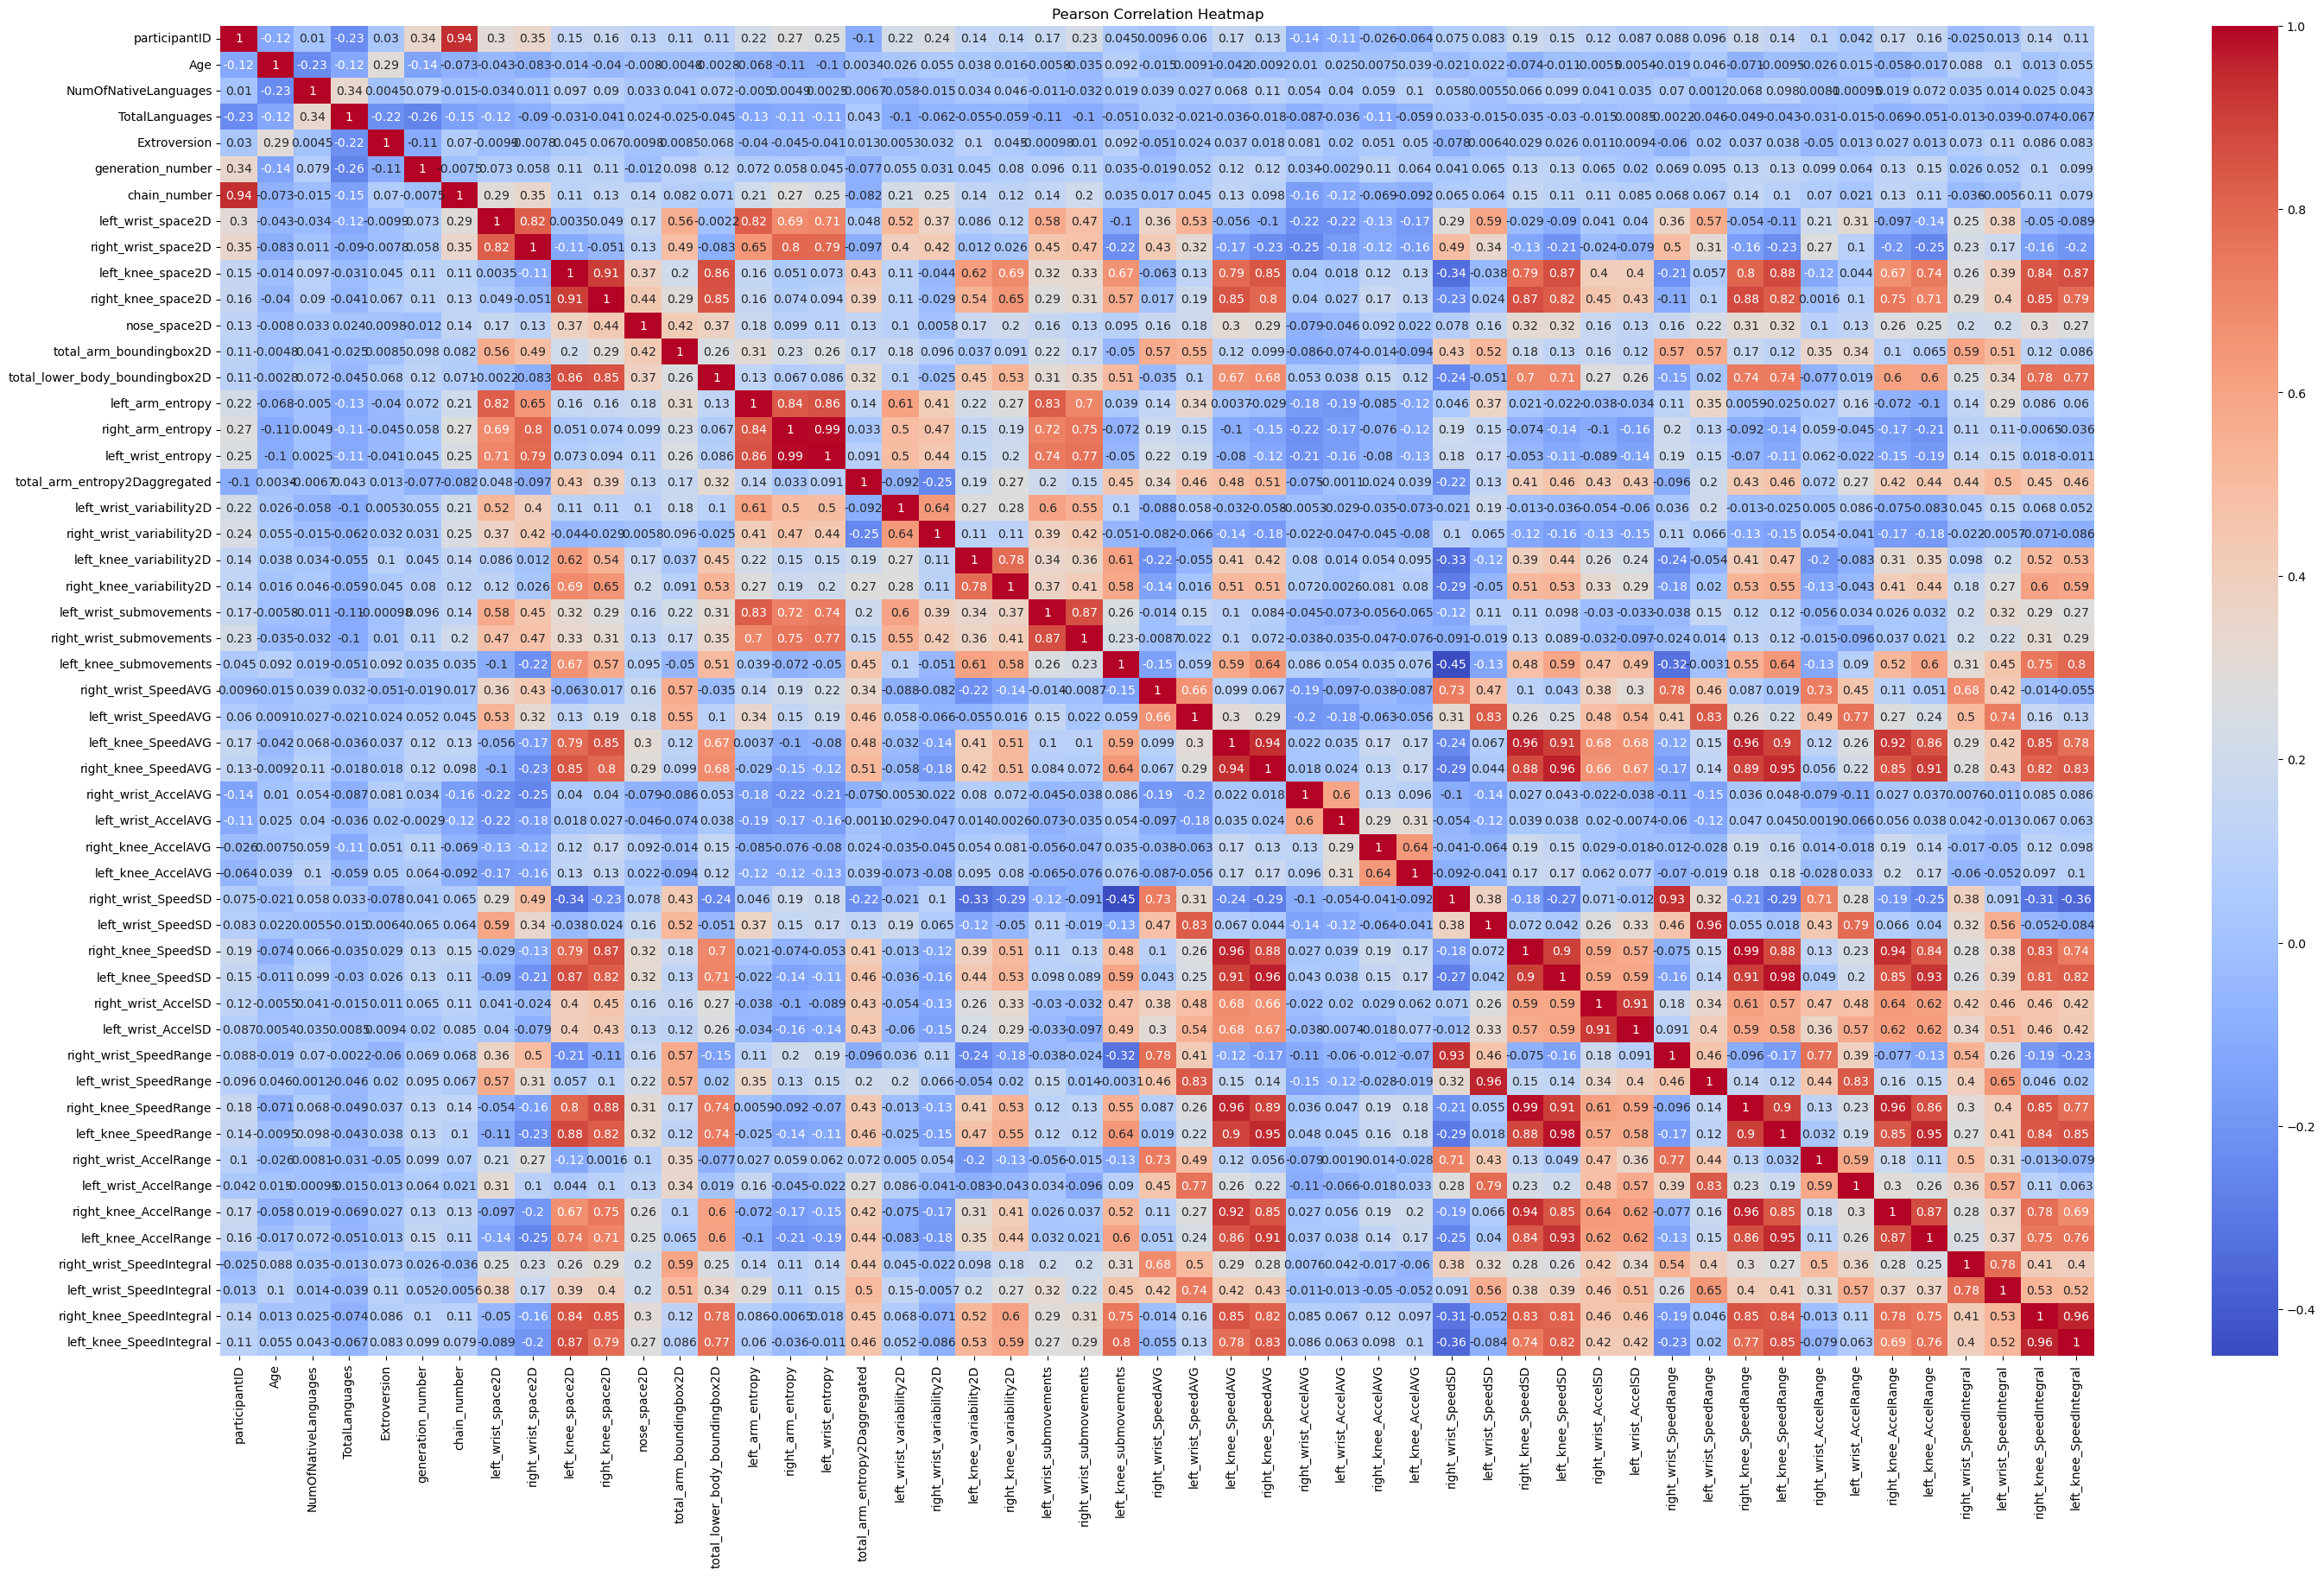

In [9]:
## testing the correlations
import seaborn as sns
import matplotlib.pyplot as plt

# keep only numerical variables for correlation analysis
numerical_features = feature_extraction.select_dtypes(include=[np.number])

pearson_corr = numerical_features.corr(method='pearson')
print(pearson_corr)

# make figure big
plt.figure(figsize=(35, 20))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap")
plt.show()

#np.corrcoef(feature_extraction['right_wrist_space2D'], feature_extraction['left_wrist_entropy2D'])

In [24]:
high_corrs = []

for col in pearson_corr.columns:
    for idx in pearson_corr.index:
        if col != idx and abs(pearson_corr.loc[idx, col]) > 0.8:
            pair = tuple(sorted([col, idx]))
            if pair not in [(a, b) for a, b, _ in high_corrs]:
                high_corrs.append((pair[0], pair[1], pearson_corr.loc[idx, col]))


In [25]:
# make high_corrs into a dataframe
high_corrs_df = pd.DataFrame(high_corrs, columns=['Feature 1', 'Feature 2', 'Correlation'])
high_corrs_df


,Feature 1,Feature 2,Correlation
0,chain_number,participantID,0.938012
1,left_wrist_space2D,right_wrist_space2D,0.820869
2,left_arm_entropy,left_wrist_space2D,0.824283
3,left_knee_space2D,right_knee_space2D,0.907970
4,left_knee_space2D,total_lower_body_boundingbox2D,0.858906
...,...,...,...
63,left_knee_AccelRange,left_knee_SpeedRange,0.945994
64,left_knee_SpeedRange,right_knee_SpeedIntegral,0.839683
65,left_knee_SpeedIntegral,left_knee_SpeedRange,0.853428
66,left_knee_AccelRange,right_knee_AccelRange,0.874696
